In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib as mpl
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from datetime import datetime

import argparse
import os
import ast

import fsspec
import numpy as np
import pandas as pd
import xarray as xr
import goes2go
import pandas as pd
from tqdm import tqdm
from satpy import Scene

In [3]:
ibtracs_file = 'files/ibtracs.ALL.list.v04r01.csv'
ibtracs_na_file = 'files/ibtracs.NA.list.v04r01.csv' # North Atlantic
ibtracs_ep_file = 'files/ibtracs.EP.list.v04r01.csv' # Eastern Pacific
ibtracs_wp_file = 'files/ibtracs.WP.list.v04r01.csv' # Western Pacific
ibtracs_sp_file = 'files/ibtracs.SP.list.v04r01.csv' # South Pacific
ibtracs_si_file = 'files/ibtracs.SI.list.v04r01.csv' # South Indian
ibtracs_sa_file = 'files/ibtracs.SA.list.v04r01.csv' # South Atlantic
ibtracs_ni_file = 'files/ibtracs.NI.list.v04r01.csv' # North Indian Ocean

In [4]:
df = pd.read_csv(ibtracs_file, keep_default_na=False)
df_na = pd.read_csv(ibtracs_na_file, keep_default_na=False)
df_na['BASIN'] = ['NA'] * len(df_na)
df_ep = pd.read_csv(ibtracs_ep_file, keep_default_na=False)
df_ep['BASIN'] = ['EP'] * len(df_ep)
df_wp = pd.read_csv(ibtracs_wp_file, keep_default_na=False)
df_wp['BASIN'] = ['WP'] * len(df_wp)
df_sp = pd.read_csv(ibtracs_sp_file, keep_default_na=False)
df_sp['BASIN'] = ['SP'] * len(df_sp)
df_si = pd.read_csv(ibtracs_si_file, keep_default_na=False)
df_si['BASIN'] = ['SI'] * len(df_si)
df_sa = pd.read_csv(ibtracs_sa_file, keep_default_na=False)
df_sa['BASIN'] = ['SA'] * len(df_sa)
df_ni = pd.read_csv(ibtracs_ni_file, keep_default_na=False)
df_ni['BASIN'] = ['NI'] * len(df_ni)

/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/2499292159.py:1: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ibtracs_file, keep_default_na=False)
/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/2499292159.py:2: DtypeWarning: Columns (1,2,8,9,14,19,20,23,24,26,27,28,29,30,31,32,33,38,39,40,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_na = pd.read_csv(ibtracs_na_file, keep_default_na=False)
/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/2499292159.py:4: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ep = pd.read_csv(ibtracs_ep_file, keep_default_na=False)
/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/2499292159.py:6: DtypeWarning: Columns (1,2,8,9,14,142,143,144,172,173) have mixed types. Specify dtype option on

In [5]:
df_cyclobs = pd.read_csv('./files/master-cyclobs-[2023-2025].csv', keep_default_na=False)

In [6]:
# Combine all dataframes
df_all = pd.concat([df_na, df_ep, df_wp, df_sp, df_si, df_sa, df_ni], ignore_index=True)
# Filter for seasons 2023-2026
df_all = df_all[df_all['SEASON'].isin([2023, 2024, 2025])]
print('Number of storms before filtering for CYCLOBS storms: ', len(df_all['USA_ATCF_ID'].unique()))

Number of storms before filtering for CYCLOBS storms:  282


In [7]:
# Filter the storms that are also in TC PRIMED
cyclobs_storms = df_cyclobs.storm_id.unique()
df_matched = df_all[df_all['USA_ATCF_ID'].str.lower().isin(cyclobs_storms)]
print('Number of storms after filtering for CYCLOBS storms: ', len(df_matched['USA_ATCF_ID'].unique()))

Number of storms after filtering for CYCLOBS storms:  233


In [8]:
df_matched.head()


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
123849,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 00:00:00,ET,36.4,-71.3,...,,,,,,,,,7,55
123850,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 03:00:00,ET,36.6,-71.0,...,,,,,,,,,7,55
123851,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 06:00:00,ET,36.8,-70.6,...,,,,,,,,,8,55
123852,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 09:00:00,ET,37.0,-70.2,...,,,,,,,,,8,60
123853,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 12:00:00,ET,37.2,-69.7,...,,,,,,,,,8,70


### Filter Geostationary Fields-Of-View

In [9]:
GOES_EAST_COORDS = (-75.0, 0.0)  # Longitude, Latitude
GOES_WEST_COORDS = (-137.0, 0.0)  # Longitude, Latitude
HIMAWARI_COORDS = (140.7, 35.5)  # Longitude, Latitude

fov_bounds = {
    'GOES-East': {
        'lon_min': GOES_EAST_COORDS[0] - 60,
        'lon_max': GOES_EAST_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    },
    'GOES-West': {
        'lon_min': GOES_WEST_COORDS[0] - 60,
        'lon_max': GOES_WEST_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    },
    'Himawari': {
        'lon_min': HIMAWARI_COORDS[0] - 60,
        'lon_max': HIMAWARI_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    }
}

In [31]:
df_matched

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
123849,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 00:00:00,ET,36.4,-71.3,...,,,,,,,,,7,55
123850,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 03:00:00,ET,36.6,-71.0,...,,,,,,,,,7,55
123851,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 06:00:00,ET,36.8,-70.6,...,,,,,,,,,8,55
123852,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 09:00:00,ET,37.0,-70.2,...,,,,,,,,,8,60
123853,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 12:00:00,ET,37.2,-69.7,...,,,,,,,,,8,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783827,2025331N07081,2025,103,NI,BB,DITWAH,2025-12-02 00:00:00,NR,12.5,80.6,...,,,,,,,,,2,130
783828,2025331N07081,2025,103,NI,BB,DITWAH,2025-12-02 03:00:00,NR,12.4,80.8,...,,,,,,,,,4,125
783829,2025331N07081,2025,103,NI,BB,DITWAH,2025-12-02 06:00:00,NR,12.3,80.9,...,,,,,,,,,2,160
783830,2025331N07081,2025,103,NI,BB,DITWAH,2025-12-02 09:00:00,NR,12.2,80.8,...,,,,,,,,,3,250


In [42]:
# Match the tropical cyclones to their corresponding geostationary satellites
# We need to filter for the correct FOV
# And match each storm to the closest satellite based on their longitude
# This way, we can avoid duplicates, and switches within storms

df_sat_match = df_matched.copy() # Start from the storms that have already been matched with CYCLOBS
# Add boolean to check which storms and timesteps are within the satellite FOVs
df_sat_match['GOES_FOV'] = df_sat_match.LAT.between(-60, 60) & df_sat_match.LON.between(GOES_WEST_COORDS[0] - 60, GOES_EAST_COORDS[0] + 60)
df_sat_match['GOES_EAST_FOV'] = df_sat_match.LAT.between(-60, 60) & df_sat_match.LON.between(GOES_EAST_COORDS[0] - 60, GOES_EAST_COORDS[0] + 60)
df_sat_match['GOES_WEST_FOV'] = df_sat_match.LAT.between(-60, 60) & df_sat_match.LON.between(GOES_WEST_COORDS[0] - 60, GOES_WEST_COORDS[0] + 60)
df_sat_match['HIMAWARI_FOV'] = df_sat_match.LAT.between(-60, 60) & df_sat_match.LON.between(HIMAWARI_COORDS[0] - 60, HIMAWARI_COORDS[0] + 60)

In [43]:
# Calculate the difference between the storm's longitude and each satellite's longitude
df_sat_match['GOES_EAST_DIFF'] = (df_sat_match.LON - GOES_EAST_COORDS[0]).abs()
df_sat_match['GOES_WEST_DIFF'] = (df_sat_match.LON - GOES_WEST_COORDS[0]).abs()
df_sat_match['HIMAWARI_DIFF'] = (df_sat_match.LON - HIMAWARI_COORDS[0]).abs()

In [44]:
satellites = {
    'GOES_EAST': 'GOES_EAST_DIFF',
    'GOES_WEST': 'GOES_WEST_DIFF',
    'HIMAWARI':  'HIMAWARI_DIFF',
}
fov_cols = {sat: f'{sat}_FOV' for sat in satellites}

best_match = {}

for storm in df_sat_match['USA_ATCF_ID'].unique():
    df_storm = df_sat_match[df_sat_match['USA_ATCF_ID'] == storm].copy()

    # For each timestep, find the closest in-FOV satellite
    def closest_for_row(row):
        candidates = {
            sat: row[diff_col]
            for sat, diff_col in satellites.items()
            if row[fov_cols[sat]] # Only consider satellites that are in the field of view
        }
        return min(candidates, key=candidates.get) if candidates else None

    df_storm['best_sat'] = df_storm.apply(closest_for_row, axis=1)

    # Assign the satellite that wins the most timesteps
    counts = df_storm['best_sat'].value_counts()
    best_match[storm] = counts.idxmax() if not counts.empty else None

df_sat_match['BEST_SATELLITE_MATCH'] = df_sat_match['USA_ATCF_ID'].map(best_match)


In [45]:
df_sat_match.to_csv('matched-ibtracs-[2023-2025].csv')

In [46]:
df_sat_match.BEST_SATELLITE_MATCH.unique()

array(['GOES_EAST', 'HIMAWARI', 'GOES_WEST', None], dtype=object)

In [47]:
df_sat_match.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,STORM_SPEED,STORM_DIR,GOES_FOV,GOES_EAST_FOV,GOES_WEST_FOV,HIMAWARI_FOV,GOES_EAST_DIFF,GOES_WEST_DIFF,HIMAWARI_DIFF,BEST_SATELLITE_MATCH
123849,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 00:00:00,ET,36.4,-71.3,...,7,55,True,True,False,False,3.7,65.7,212.0,GOES_EAST
123850,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 03:00:00,ET,36.6,-71.0,...,7,55,True,True,False,False,4.0,66.0,211.7,GOES_EAST
123851,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 06:00:00,ET,36.8,-70.6,...,8,55,True,True,False,False,4.4,66.4,211.3,GOES_EAST
123852,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 09:00:00,ET,37.0,-70.2,...,8,60,True,True,False,False,4.8,66.8,210.9,GOES_EAST
123853,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 12:00:00,ET,37.2,-69.7,...,8,70,True,True,False,False,5.3,67.3,210.4,GOES_EAST


In [50]:
# Now extract each storm's best satellite match
# Check that each observation is in the satellite FOV, and that the overall best satellite match aligns with the FOV availability
df_goes_tcs = df_sat_match[(df_sat_match['GOES_FOV']) & ((df_sat_match['BEST_SATELLITE_MATCH'] == 'GOES_EAST') | (df_sat_match['BEST_SATELLITE_MATCH'] == 'GOES_WEST'))]
df_goes_east_tcs = df_sat_match[df_sat_match['GOES_EAST_FOV'] & (df_sat_match['BEST_SATELLITE_MATCH'] == 'GOES_EAST')]
df_goes_west_tcs = df_sat_match[df_sat_match['GOES_WEST_FOV'] & (df_sat_match['BEST_SATELLITE_MATCH'] == 'GOES_WEST')]
df_himawari_tcs = df_sat_match[df_sat_match['HIMAWARI_FOV'] & (df_sat_match['BEST_SATELLITE_MATCH'] == 'HIMAWARI')]

In [51]:
# NOTE: There could be duplicates in here:
print('Number of unique storms in each dataset:')
print('GOES (ALL): ', len(df_goes_tcs.SID.unique()))
print('GOES (EAST): ', len(df_goes_east_tcs.SID.unique()))
print('GOES (WEST): ', len(df_goes_west_tcs.SID.unique()))
print('HIMAWARI: ', len(df_himawari_tcs.SID.unique()))

Number of unique storms in each dataset:
GOES (ALL):  100
GOES (EAST):  55
GOES (WEST):  45
HIMAWARI:  111


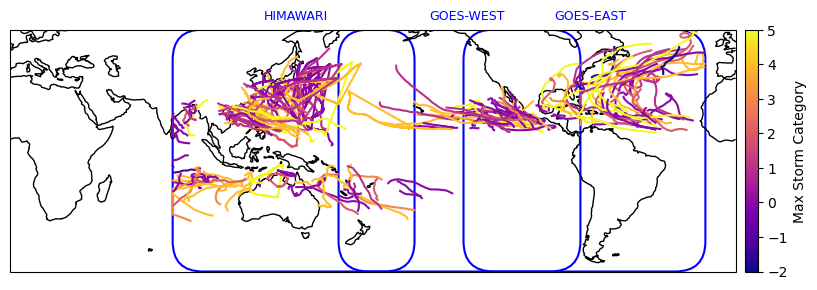

In [80]:
# Plot tracks on map
fig, ax = plt.subplots(figsize=(20, 3),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.set_extent([0, 359.99, -60, 60], crs=ccrs.PlateCarree())


# plot every track with colour for category
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=-2, vmax=5)

grouped = df_goes_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=cmap(norm(max_cat)))

grouped = df_himawari_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=cmap(norm(max_cat)))

# Draw Field of View boxes
for sat, bounds in fov_bounds.items():
    from matplotlib.patches import FancyBboxPatch

    patch = FancyBboxPatch(
        (bounds['lon_min'], bounds['lat_min']),
        bounds['lon_max'] - bounds['lon_min'],
        bounds['lat_max'] - bounds['lat_min'],
        boxstyle="round,pad=0,rounding_size=15",  # rounding_size in degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor='blue',
        facecolor='none',
    )
    ax.add_patch(patch)

    ax.text((bounds['lon_min'] + bounds['lon_max']) / 2 - 15, bounds['lat_max'] + 5, sat.upper(), transform=ccrs.PlateCarree(), fontsize=9, color='Blue')


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable with colorbar
plt.colorbar(sm, ax=ax, label='Max Storm Category', pad=0.005)
# plt.title('IBTrACS tracks from 2023 onwards')

plt.tight_layout()

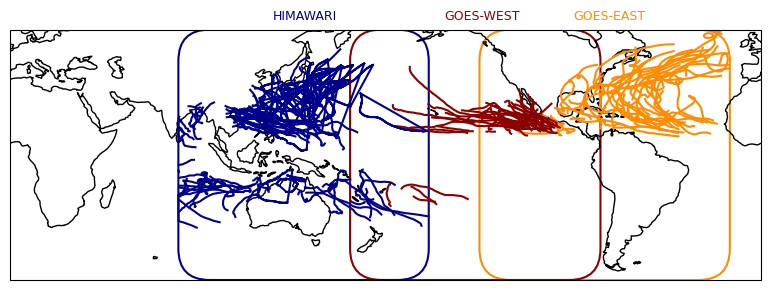

In [82]:
# Plot tracks on map
fig, ax = plt.subplots(figsize=(20, 3),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.set_extent([0, 359.99, -60, 60], crs=ccrs.PlateCarree())


# plot every track with colour for category
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=-2, vmax=5)

colors = {
    'goes-east': 'darkorange',
    'goes-west': 'darkred',
    'himawari': 'darkblue',
}

grouped = df_goes_east_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=colors['goes-east'])

grouped = df_goes_west_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=colors['goes-west'])

grouped = df_himawari_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=colors['himawari'])

# Draw Field of View boxes
for sat, bounds in fov_bounds.items():
    from matplotlib.patches import FancyBboxPatch

    patch = FancyBboxPatch(
        (bounds['lon_min'], bounds['lat_min']),
        bounds['lon_max'] - bounds['lon_min'],
        bounds['lat_max'] - bounds['lat_min'],
        boxstyle="round,pad=0,rounding_size=15",  # rounding_size in degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor=colors[sat.lower()],
        facecolor='none'
    )
    ax.add_patch(patch)

    ax.text((bounds['lon_min'] + bounds['lon_max']) / 2 - 15, bounds['lat_max'] + 5, sat.upper(), transform=ccrs.PlateCarree(), fontsize=9, color=colors[sat.lower()])


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable with colorbar
# plt.colorbar(sm, ax=ax, label='Max Storm Category', pad=0.005)
# plt.title('IBTrACS tracks from 2023 onwards')

plt.tight_layout()

In [91]:
# Assign the right satellite and save to csv
df_himawari_tcs['SATELLITE'] = ['noaa-himawari9'] * len(df_himawari_tcs)
df_himawari_tcs.to_csv('./files/matched-ibtracs-himawari-[2023-2025].csv', index=False)

/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/2871940127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_himawari_tcs['SATELLITE'] = ['noaa-himawari9'] * len(df_himawari_tcs)


In [92]:
df_goes_west_tcs['SATELLITE'] = ['noaa-goes18'] * len(df_goes_west_tcs)
df_goes_west_tcs.to_csv('./files/matched-ibtracs-goes-west-[2023-2025].csv', index=False)

/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/298820055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_goes_west_tcs['SATELLITE'] = ['noaa-goes18'] * len(df_goes_west_tcs)


In [100]:
times = pd.to_datetime(df_goes_east_tcs['ISO_TIME'])
# Assign 'noaa-goes16' to times before the first of April 2025, and 'noaa-goes19' afterwards
satellite_assignment = ['noaa-goes16' if t < pd.Timestamp('2025-04-01') else 'noaa-goes19' for t in times]
df_goes_east_tcs['SATELLITE'] = satellite_assignment
df_goes_east_tcs.to_csv('./files/matched-ibtracs-goes-east-[2023-2025].csv', index=False)

/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_76316/356991554.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_goes_east_tcs['SATELLITE'] = satellite_assignment


In [102]:
len(df_goes_east_tcs[df_goes_east_tcs['SATELLITE']=='noaa-goes16'].SID.unique()), len(df_goes_east_tcs[df_goes_east_tcs['SATELLITE']=='noaa-goes19'].SID.unique())

(41, 14)

In [106]:
for SID in df_goes_east_tcs['SID'].unique():
    # print(f"SID: {SID}, SATELLITES: {df_goes_east_tcs[df_goes_east_tcs['SID'] == SID]['SATELLITE'].unique()}")
    if len(df_goes_east_tcs[df_goes_east_tcs['SID'] == SID]['SATELLITE'].unique()) > 1:
        print(f"SID: {SID} has multiple satellites!")

In [108]:
df_himawari_tcs[df_himawari_tcs['SID'] == '2023156N12135']

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,STORM_DIR,GOES_FOV,GOES_EAST_FOV,GOES_WEST_FOV,HIMAWARI_FOV,GOES_EAST_DIFF,GOES_WEST_DIFF,HIMAWARI_DIFF,BEST_SATELLITE_MATCH,SATELLITE
222252,2023156N12135,2023,24,EP,MM,GUCHOL,2023-06-04 18:00:00,DS,11.7,135.0,...,290,False,False,False,True,210.0,272.0,5.7,HIMAWARI,noaa-himawari9
222253,2023156N12135,2023,24,EP,MM,GUCHOL,2023-06-04 21:00:00,DS,11.8,134.8,...,295,False,False,False,True,209.8,271.8,5.9,HIMAWARI,noaa-himawari9
222254,2023156N12135,2023,24,EP,MM,GUCHOL,2023-06-05 00:00:00,DS,11.9,134.6,...,320,False,False,False,True,209.6,271.6,6.1,HIMAWARI,noaa-himawari9
222255,2023156N12135,2023,24,EP,MM,GUCHOL,2023-06-05 03:00:00,DS,12.1,134.5,...,345,False,False,False,True,209.5,271.5,6.2,HIMAWARI,noaa-himawari9
222256,2023156N12135,2023,24,EP,MM,GUCHOL,2023-06-05 06:00:00,DS,12.3,134.5,...,355,False,False,False,True,209.5,271.5,6.2,HIMAWARI,noaa-himawari9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468538,2023156N12135,2023,24,WP,MM,GUCHOL,2023-06-12 15:00:00,MX,31.3,140.6,...,50,False,False,False,True,215.6,277.6,0.1,HIMAWARI,noaa-himawari9
468539,2023156N12135,2023,24,WP,MM,GUCHOL,2023-06-12 18:00:00,MX,32.1,141.9,...,50,False,False,False,True,216.9,278.9,1.2,HIMAWARI,noaa-himawari9
468540,2023156N12135,2023,24,WP,MM,GUCHOL,2023-06-12 21:00:00,MX,32.9,142.9,...,50,False,False,False,True,217.9,279.9,2.2,HIMAWARI,noaa-himawari9
468541,2023156N12135,2023,24,WP,MM,GUCHOL,2023-06-13 00:00:00,MX,33.7,144.0,...,60,False,False,False,True,219.0,281.0,3.3,HIMAWARI,noaa-himawari9


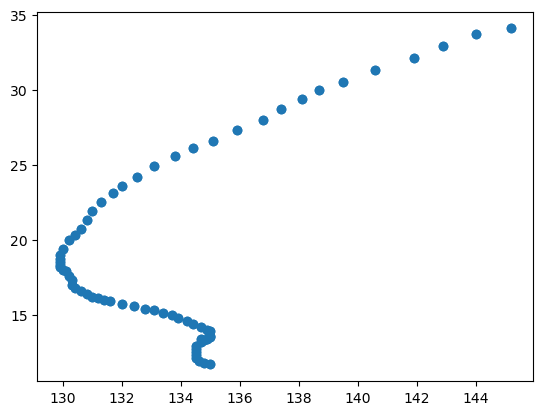

In [109]:
plt.scatter(df_himawari_tcs[df_himawari_tcs['SID'] == '2023156N12135']['LON'], df_himawari_tcs[df_himawari_tcs['SID'] == '2023156N12135']['LAT'])

In [111]:
test = pd.read_csv('matched-himawari-[2023-2025].csv')

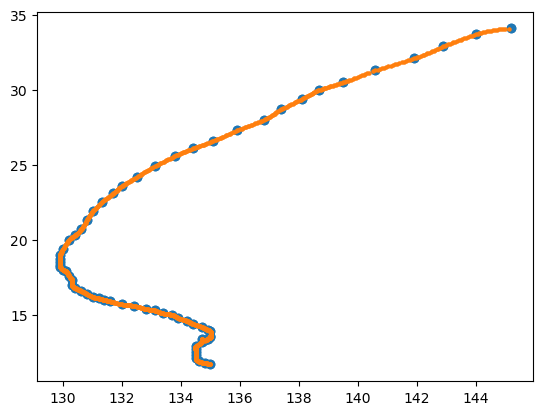

In [114]:
plt.scatter(df_himawari_tcs[df_himawari_tcs['SID'] == '2023156N12135']['LON'], df_himawari_tcs[df_himawari_tcs['SID'] == '2023156N12135']['LAT'])
plt.scatter(test[test['SID'] == '2023156N12135']['LON'], test[test['SID'] == '2023156N12135']['LAT'], s=5)